In [1]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
import matplotlib.pyplot as plt
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from dataset.dataset import *
from utils.animation.skeleton import Skeleton
import utils.utils as utils
import pickle
from torch.amp import autocast
import time

device = utils.get_device()

In [2]:
dataset = GPUDataset(
    consolidated_file="dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=2000, # For testing
    seed_length=0,
    batch_size=1,
    epoch_length=1,  # Set to 1 for testing purposes
    return_audio_frame_index=True,  # Set to True to return the audio frame index
)

model = AdvancedPoseEncoder(
    pose_dim=345,
    component_definitions = {
        # Preserved (no encoding/decoding)
        'world_pos': {
            'bone_names': ['body_world'],
            'type': 'preserve',
            'use_position': True
        },
        'left_hand_rot': {
            'bone_name': 'b_l_wrist',
            'type': 'world_preserve_after_ik'
        },
        'right_hand_rot': {
            'bone_name': 'b_r_wrist',
            'type': 'world_preserve_after_ik'
        },
        'left_foot_rot': {
            'bone_name': 'b_l_foot',
            'type': 'world_preserve_after_ik'
        },
        'right_foot_rot': {
            'bone_name': 'b_r_foot',
            'type': 'world_preserve_after_ik'
        },
        # Auto-encoded components - explicit bone lists
        'spine_shoulders_head': {
            'bone_names': [
                'b_root', 'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3',
                'b_l_shoulder', 'b_r_shoulder', 'b_neck0', 'b_head'
            ],
            'type': 'encode',
            'z_dim': 5
        },
        'left_hand_fingers': {
            'bone_names': [
                # Left thumb
                'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3',
                # Left fingers  
                'b_l_index1', 'b_l_index2', 'b_l_index3',
                'b_l_middle1', 'b_l_middle2', 'b_l_middle3',
                'b_l_ring1', 'b_l_ring2', 'b_l_ring3',
                'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3'
            ],
            'type': 'encode',
            'z_dim': 8
        },
        'right_hand_fingers': {
            'bone_names': [
                # Right thumb
                'b_r_thumb0', 'b_r_thumb1', 'b_r_thumb2', 'b_r_thumb3',
                # Right fingers
                'b_r_index1', 'b_r_index2', 'b_r_index3',
                'b_r_middle1', 'b_r_middle2', 'b_r_middle3',
                'b_r_ring1', 'b_r_ring2', 'b_r_ring3',
                'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3'
            ],
            'type': 'encode',
            'z_dim': 8
        },
        # IK components - using skeleton's enhanced chain info
        'left_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_arm', 'b_l_forearm'],
            'end_effector': 'b_l_wrist',
            'z_dim': 4,  # 3 for target position + 1 swivel rotation
            'twist_joint': 'b_l_arm_twist',
            'chain_parent': 'b_l_shoulder',
            'bone1_forward_dir': [0.9993694424629211, -0.023177823051810265, -0.026897454634308815],
            'bone1_up_dir': [-0.02316943369805813, -0.9997313618659973, 0.0006235920009203255],
            'bone2_forward_dir': [0.9993695020675659, -0.02317732758820057, -0.026897458359599113],
            'bone2_up_dir': [-0.023168936371803284, -0.9997313618659973, 0.0006235786713659763],
        },
        'right_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_arm', 'b_r_forearm'],
            'end_effector': 'b_r_wrist',
            'z_dim': 4,
            'twist_joint': 'b_r_arm_twist',
            'chain_parent': 'b_r_shoulder',
            'bone1_forward_dir': [-0.9992618560791016, -0.028031472116708755, -0.026267891749739647],
            'bone1_up_dir': [0.02802179381251335, -0.9996070861816406, 0.0007366171339526772],
            'bone2_forward_dir': [-0.9992617964744568, -0.028031865134835243, -0.02626790478825569],
            'bone2_up_dir': [0.02802218683063984, -0.9996070265769958, 0.0007366279023699462],
        },
        'left_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_upleg', 'b_l_leg'],
            'end_effector': 'b_l_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097],
            'bone1_up_dir': [0.0, 0.007038275711238384, 0.9999752640724182],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420658826828],
            'bone2_up_dir': [0.0, 0.0801420658826828, -0.996783435344696],
        },
        'right_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_upleg', 'b_r_leg'],
            'end_effector': 'b_r_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361],
            'bone1_up_dir': [0.0, 0.0043573565781116486, 0.9999905228614807],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420733332634],
            'bone2_up_dir': [0.0, 0.0801420733332634, -0.996783435344696],
        }
    },
    skeleton = dataset.skeleton,
    device = utils.get_device(),
    checkpoint_path="advanced_pose_encoder_64.pth"
)

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/toy/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([49628, 345]), Audio shape: torch.Size([49628, 37])
Found 28416 valid starting points for windows
Dataset initialization complete!

Unhandled bones that will use identity rotation:
  b_r_arm_twist: indices 57-62
  b_r_wrist_twist: indices 69-74
  b_l_arm_twist: indices 189-194
  b_l_wrist_twist: indices 201-206

=== Pose Encoder Component Information ===

world_pos (preserve):
  Indices: [0, 1, 2]
  Dimensions: 3

left_hand_rot (world_preserve_after_ik):

right_hand_rot (world_preserve_after_ik):

left_foot_rot (world_preserve_after_ik):

right_foot_rot (world_preserve_after_ik):

spine_shoulders_head (encode):
  Input dimensions: 54
  Latent dimensions: 5
  Indices range: [3, 182]

left_hand_fingers (encode):
  Input dimensions: 96
  Latent dimensions: 8
  Indices range: [213, 308]

right_hand_fingers (en

In [3]:
# Import the viewer
import utils.animation.visualisation.new.animation_visualisation as animation_visualisation
animation_visualisation.init_visualization()
time.sleep(1.0) # Give the visualisation time to start before we send messages
animation_visualisation.send_character("ground_truth", (1.0,0.0,0.0), 0, "red")

Viewer URL: http://localhost:8000/utils/animation/visualisation/new/animation_viewer2.html?wsport=8700


In [5]:
model.to(device)  # Move the model to the appropriate device
model.eval()  # Set the model to evaluation mode
# Use no gradient calculation for inference
with torch.no_grad():
    # Get a sample from the dataset
    # gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame, file = next(iter(dataset))
    gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, start_frames = next(iter(dataset))
    gesture_sequence = gesture_sequence.to(device)
    seed_gesture = seed_gesture.to(device)
    audio_features = audio_features.to(device)
    main_agent_id_one_hot = main_agent_id_one_hot.to(device)
    full_audio_features = dataset.audio.to(device)
    start_frame = start_frames[0].item()  # Extract the first element from the tensor


    with autocast(device_type=device.type, dtype=torch.bfloat16):
        # Decode the output using the autoencoder model
        gesture_sequence = gesture_sequence  # remove the batch dimension
        print("Gesture sequence dtype:", gesture_sequence.dtype)

        gesture_sequence_encoded = model.encode(gesture_sequence)

        print("Encoded gesture sequence dtype:", gesture_sequence_encoded.dtype)

        # Decode the output using the autoencoder model
        gesture_sequence_decoded = model.decode(gesture_sequence_encoded)

    # Undo the z-score normalization
    unnormalized_encoded_gesture_sequence = dataset.skeleton.denormalize_poses(gesture_sequence_decoded).squeeze(0).cpu()
    unnormalized_ground_truth_gesture_sequence = dataset.skeleton.denormalize_poses(gesture_sequence).squeeze(0).cpu()

    for i in range(unnormalized_encoded_gesture_sequence.shape[0]):
        animation_visualisation.send_pose(unnormalized_encoded_gesture_sequence[i], dataset.skeleton)
        animation_visualisation.send_pose(unnormalized_ground_truth_gesture_sequence[i], dataset.skeleton, "ground_truth")
        time.sleep(1.0/30.0) # # Assuming 30 FPS for the animation

Gesture sequence dtype: torch.float16


RuntimeError: The expanded size of the tensor (3) must match the existing size (345) at non-singleton dimension 1.  Target sizes: [1, 3].  Tensor sizes: [3, 345]

In [ ]:
# Load std_pose and mean_pose from statistics.npz
with open("dataset/genea2023_dataset/trn/main-agent/consolidated_meta.pkl", 'rb') as f:
    skeleton: Skeleton = pickle.load(f)['skeleton']
    skeleton.set_device(device)

with torch.no_grad():
    # Generate two random poses and interpolate between them
    sample1 = torch.randn(1, model.z_dim).to(device)  # Sample random z-values
    pose1 = model.decode(sample1)

    # Get the first 64 samples from the dataset
    for i in range(64):
        
        sample2 = torch.randn(1, model.z_dim).to(device)  # Sample random z-values
        pose2 = model.decode(sample2)

        for alpha in torch.linspace(0, 1, 40):
            # Interpolate between the two poses
            x_reconstructed = (1 - alpha) * pose1 + alpha * pose2

            # unormalize the reconstructed pose
            x_reconstructed_unnormalized = skeleton.denormalize_poses(x_reconstructed)

            # Send the reconstructed pose to the viewer
            reconstructed_frame = animation_visualisation.add_pose_to_message(x_reconstructed_unnormalized.squeeze(0).cpu(), skeleton)
            animation_visualisation.send_message(reconstructed_frame)
        # animation_visualisation.send_frame(reconstructed_frame)

        # Update pose1 to pose2 for the next iteration
        pose1 = pose2

AttributeError: 'AdvancedPoseEncoder' object has no attribute 'z_dim'

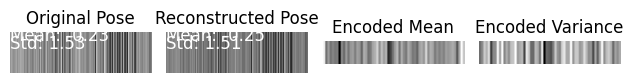

Original pose sent to viewer
Reconstructed pose sent to viewer


KeyboardInterrupt: 

In [ ]:
import time
from IPython.display import clear_output
from utils.animation.skeleton import Skeleton

with torch.no_grad():

    # Load the dataset
    dataset = GPUDataset(
        consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
        seq_length=1,
        seed_length=0,
        batch_size=1,
        epoch_length=64
    )

    skeleton: Skeleton = dataset.skeleton

    skeleton.set_device(device)

    # Get the first 64 samples from the dataset
    for i in range(64):
        pose, _, _, _ = [
            item.squeeze(0) for item in dataset[i]
        ]

        # pose to float # TODO: Probably dont do this
        pose = pose.float()

        # pass the pose through the model
        # x_reconstructed, mu, logvar = model(pose)
        x_encoded_mean, x_encoded_var = model.encode(pose, return_logvar=True)
        x_reconstructed = model.decode(x_encoded_mean)

        # unormalize the reconstructed pose
        x_reconstructed_unnormalized = skeleton.denormalize_poses(x_reconstructed)

        # unnormalize the original pose
        pose_unnormalized = skeleton.denormalize_poses(pose)

        # Draw a picture of the original and reconstructed pose
        plt.subplot(1, 4, 1)
        plt.imshow(pose.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Original Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {pose.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {pose.std().item():.2f}", color='white', fontsize=12)

        plt.subplot(1, 4, 2)
        plt.imshow(x_reconstructed.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Reconstructed Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {x_reconstructed.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {x_reconstructed.std().item():.2f}", color='white', fontsize=12)

        # Draw the encoded mean and variance
        plt.subplot(1, 4, 3)
        plt.imshow(x_encoded_mean.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Mean")
        plt.axis('off')
        plt.subplot(1, 4, 4)
        plt.imshow(x_encoded_var.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Variance")
        plt.axis('off')
        plt.tight_layout()

        plt.show()

        # Send the original pose to the viewer
        
        original_frame = animation_visualisation.add_pose_to_message(pose_unnormalized.squeeze(0).cpu(), skeleton)
        animation_visualisation.send_message(original_frame)
        # animation_visualisation.send_message(original_frame)

        print("Original pose sent to viewer")

        # wait for 1 seconds
        time.sleep(0.5)

        # Send the reconstructed pose to the viewer
        reconstructed_frame = animation_visualisation.add_pose_to_message(x_reconstructed_unnormalized.squeeze(0).cpu(), skeleton)
        animation_visualisation.send_message(reconstructed_frame)
        # animation_visualisation.send_frame(reconstructed_frame)

        print("Reconstructed pose sent to viewer")

        # wait for 3 seconds
        time.sleep(3)

        clear_output(wait=True)